In [38]:
import sys
import os 
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.analysis.sensitivity import SensitivityAnalyzer
from omegaconf import OmegaConf

In [39]:
parameter_ranges = OmegaConf.load('../param_config.yaml')
dependent_parameter_names = ['Pc_des']
dependent_parameters = [{'parameter_name': 'Pc_des', 'function': lambda Pa_des : Pa_des - 20000, 'dependent_param': 'Pa_des'}]

SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=1024 , calculate_second_order=True)

SA.generate_samples()
SA.rescale_samples()
samples = SA.apply_dependent_parameters(dependent_parameters)
samples

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,Pc_des
0,345.931298,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
1,350.820492,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
2,345.931298,201919.596742,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,181919.596742
3,345.931298,268431.866782,1.789658,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
4,345.931298,268431.866782,2.632068,0.145910,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28667,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000005,56.300426,20.085051,2.250420,132452.823874
28668,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000002,20.832063,20.085051,2.250420,132452.823874
28669,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000002,56.300426,31.383792,2.250420,132452.823874
28670,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000002,56.300426,20.085051,0.862373,132452.823874


In [40]:
dejvis = samples[0:15000]
camila = samples[15000:21836]
nathaly = samples[21836:]
camila

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,Pc_des
15000,344.816848,184388.228173,2.228055,0.244742,0.641935,3.528215,0.196861,0.221686,4,0.000004,67.237252,15.401462,0.954141,164388.228173
15001,344.816848,184388.228173,2.228055,0.244742,0.641935,3.528215,0.209283,0.162884,4,0.000004,67.237252,15.401462,0.954141,164388.228173
15002,344.816848,184388.228173,2.228055,0.244742,0.641935,3.528215,0.209283,0.221686,3,0.000004,67.237252,15.401462,0.954141,164388.228173
15003,344.816848,184388.228173,2.228055,0.244742,0.641935,3.528215,0.209283,0.221686,4,0.000001,67.237252,15.401462,0.954141,164388.228173
15004,344.816848,184388.228173,2.228055,0.244742,0.641935,3.528215,0.209283,0.221686,4,0.000004,62.116789,15.401462,0.954141,164388.228173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21831,355.382794,160337.531859,2.467720,0.455907,0.744422,1.312413,0.183778,0.178333,5,0.000002,59.312537,15.762654,1.069481,140337.531859
21832,355.382794,160337.531859,2.467720,0.455907,0.744422,1.757421,0.352689,0.178333,5,0.000002,59.312537,15.762654,1.069481,140337.531859
21833,355.382794,160337.531859,2.467720,0.455907,0.744422,1.757421,0.183778,0.239919,5,0.000002,59.312537,15.762654,1.069481,140337.531859
21834,355.382794,160337.531859,2.467720,0.455907,0.744422,1.757421,0.183778,0.178333,3,0.000002,59.312537,15.762654,1.069481,140337.531859


In [75]:
camila_data = pd.read_pickle('../data/raw/sobol_sampling_final_camila_compl.pkl')
data1 = pd.read_pickle('../sampling_test/results_sobol_camila5000.pkl')
data2 = pd.read_pickle('../sampling_test/results_sobol_camila6000.pkl')
data3 = pd.read_pickle('../sampling_test/results_sobol_camila6836.pkl')
camila_data

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,...,Hgc,Wgc,Lgc,Sa,Phi_a_des,a_slim,b_slim,a_switch,ifc,Ucell
0,344.816848,184388.228173,2.228055,0.244742,0.641935,3.528215,0.196861,0.221686,4,4.025105e-06,...,0.0005,0.00045,9.67,1.3,0.5,0,1,0.99,"[0.0008067185542809107, 0.10080533485236617, 0...","[0.6912067981553673, -0.17125772000575212, -0...."
1,344.816848,184388.228173,2.228055,0.244742,0.641935,3.528215,0.209283,0.162884,4,4.025105e-06,...,0.0005,0.00045,9.67,1.3,0.5,0,1,0.99,"[0.0008106533180701369, 0.10080927638692139, 0...","[0.773572546928994, 0.06079632849074024, -0.53..."
2,344.816848,184388.228173,2.228055,0.244742,0.641935,3.528215,0.209283,0.221686,3,4.025105e-06,...,0.0005,0.00045,9.67,1.3,0.5,0,1,0.99,"[0.0008075163687629004, 0.10080613404502474, 0...","[0.7737801816563441, 0.0633522841446047, -0.52..."
3,344.816848,184388.228173,2.228055,0.244742,0.641935,3.528215,0.209283,0.221686,4,1.351666e-06,...,0.0005,0.00045,9.67,1.3,0.5,0,1,0.99,"[0.0008075163687629004, 0.10080613404502474, 0...","[0.7750213775085973, 0.06730347229264622, -0.5..."
4,344.816848,184388.228173,2.228055,0.244742,0.641935,3.528215,0.209283,0.221686,4,4.025105e-06,...,0.0005,0.00045,9.67,1.3,0.5,0,1,0.99,"[0.000807637577611181, 0.10080625546301575, 0....","[0.7690721549669027, 0.05864473710018514, -0.5..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3325,361.643119,230285.376975,1.422960,0.157303,0.778666,1.041238,0.317007,0.243429,3,7.838622e-07,...,0.0005,0.00045,9.67,1.3,0.5,0,1,0.99,"[0.0008096450685679323, 0.10080826640873944, 0...","[0.9409003922981461, 0.8841194315639272, 0.845..."
3326,361.643119,193637.604552,1.554785,0.229945,0.757124,2.428410,0.229436,0.253217,5,6.400957e-07,...,0.0005,0.00045,9.67,1.3,0.5,0,1,0.99,"[0.0008180365293639134, 0.10081667212714186, 0...","[0.8805979845166476, 0.7475562152680065, 0.634..."
3327,340.927461,230285.376975,1.554785,0.229945,0.757124,2.428410,0.229436,0.253217,5,6.400957e-07,...,0.0005,0.00045,9.67,1.3,0.5,0,1,0.99,"[0.0008184298059315474, 0.10081706606473836, 0...","[0.9792767343898086, 0.9069663276310189, 0.851..."
3328,340.927461,193637.604552,1.422960,0.229945,0.757124,2.428410,0.229436,0.253217,5,6.400957e-07,...,0.0005,0.00045,9.67,1.3,0.5,0,1,0.99,"[0.0008137090894272724, 0.10081233737134095, 0...","[0.9833529113252444, 0.9025380840445906, 0.837..."


In [42]:
import pandas as pd
import glob
# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters

# Locate all pickle files in the folder
all_files = glob.glob('../sampling_test/*.pkl')

file_paths = [
    f for f in all_files
    if 'camila' not in os.path.basename(f).lower()
]

# Read each pickle file into a DataFrame and collect them
df_list = [pd.read_pickle(path) for path in file_paths]

# Concatenate all DataFrames vertically into one
combined_df = pd.concat(df_list, ignore_index=True)

# Print the overall shape
print(f"Combined DataFrame shape: {combined_df.shape}")

data = combined_df.dropna()
print(f"Data shape after dropping NaN: {data.shape}")

Combined DataFrame shape: (15000, 48)
Data shape after dropping NaN: (14982, 48)


In [6]:
# Expand Ucell
Ucell_wide = combined_df['Ucell'].apply(pd.Series)
Ucell_wide.columns = [f'Ucell_{i}' for i in Ucell_wide.columns]

# Expand ifc
ifc_wide = combined_df['ifc'].apply(pd.Series)
ifc_wide.columns = [f'ifc_{i}' for i in ifc_wide.columns]

# Combine with original DataFrame (excluding old list columns)
data = pd.concat([combined_df.drop(['Ucell', 'ifc'], axis=1), Ucell_wide, ifc_wide], axis=1)

# Identify Ucell and ifc columns
ucell_cols = [col for col in data.columns if col.startswith('Ucell_')]
ifc_cols = [col for col in data.columns if col.startswith('ifc_')]

# Combine Ucell columns into lists per row
data['Ucell'] = data[ucell_cols].values.tolist()

omegaconf_dict = OmegaConf.load('../param_config.yaml')
columns = list(omegaconf_dict.keys())
columns.extend(ifc_wide.columns.tolist())
columns.extend(Ucell_wide.columns.tolist())
data[columns].to_csv('../sampling_test/combined_data.csv', index=False)

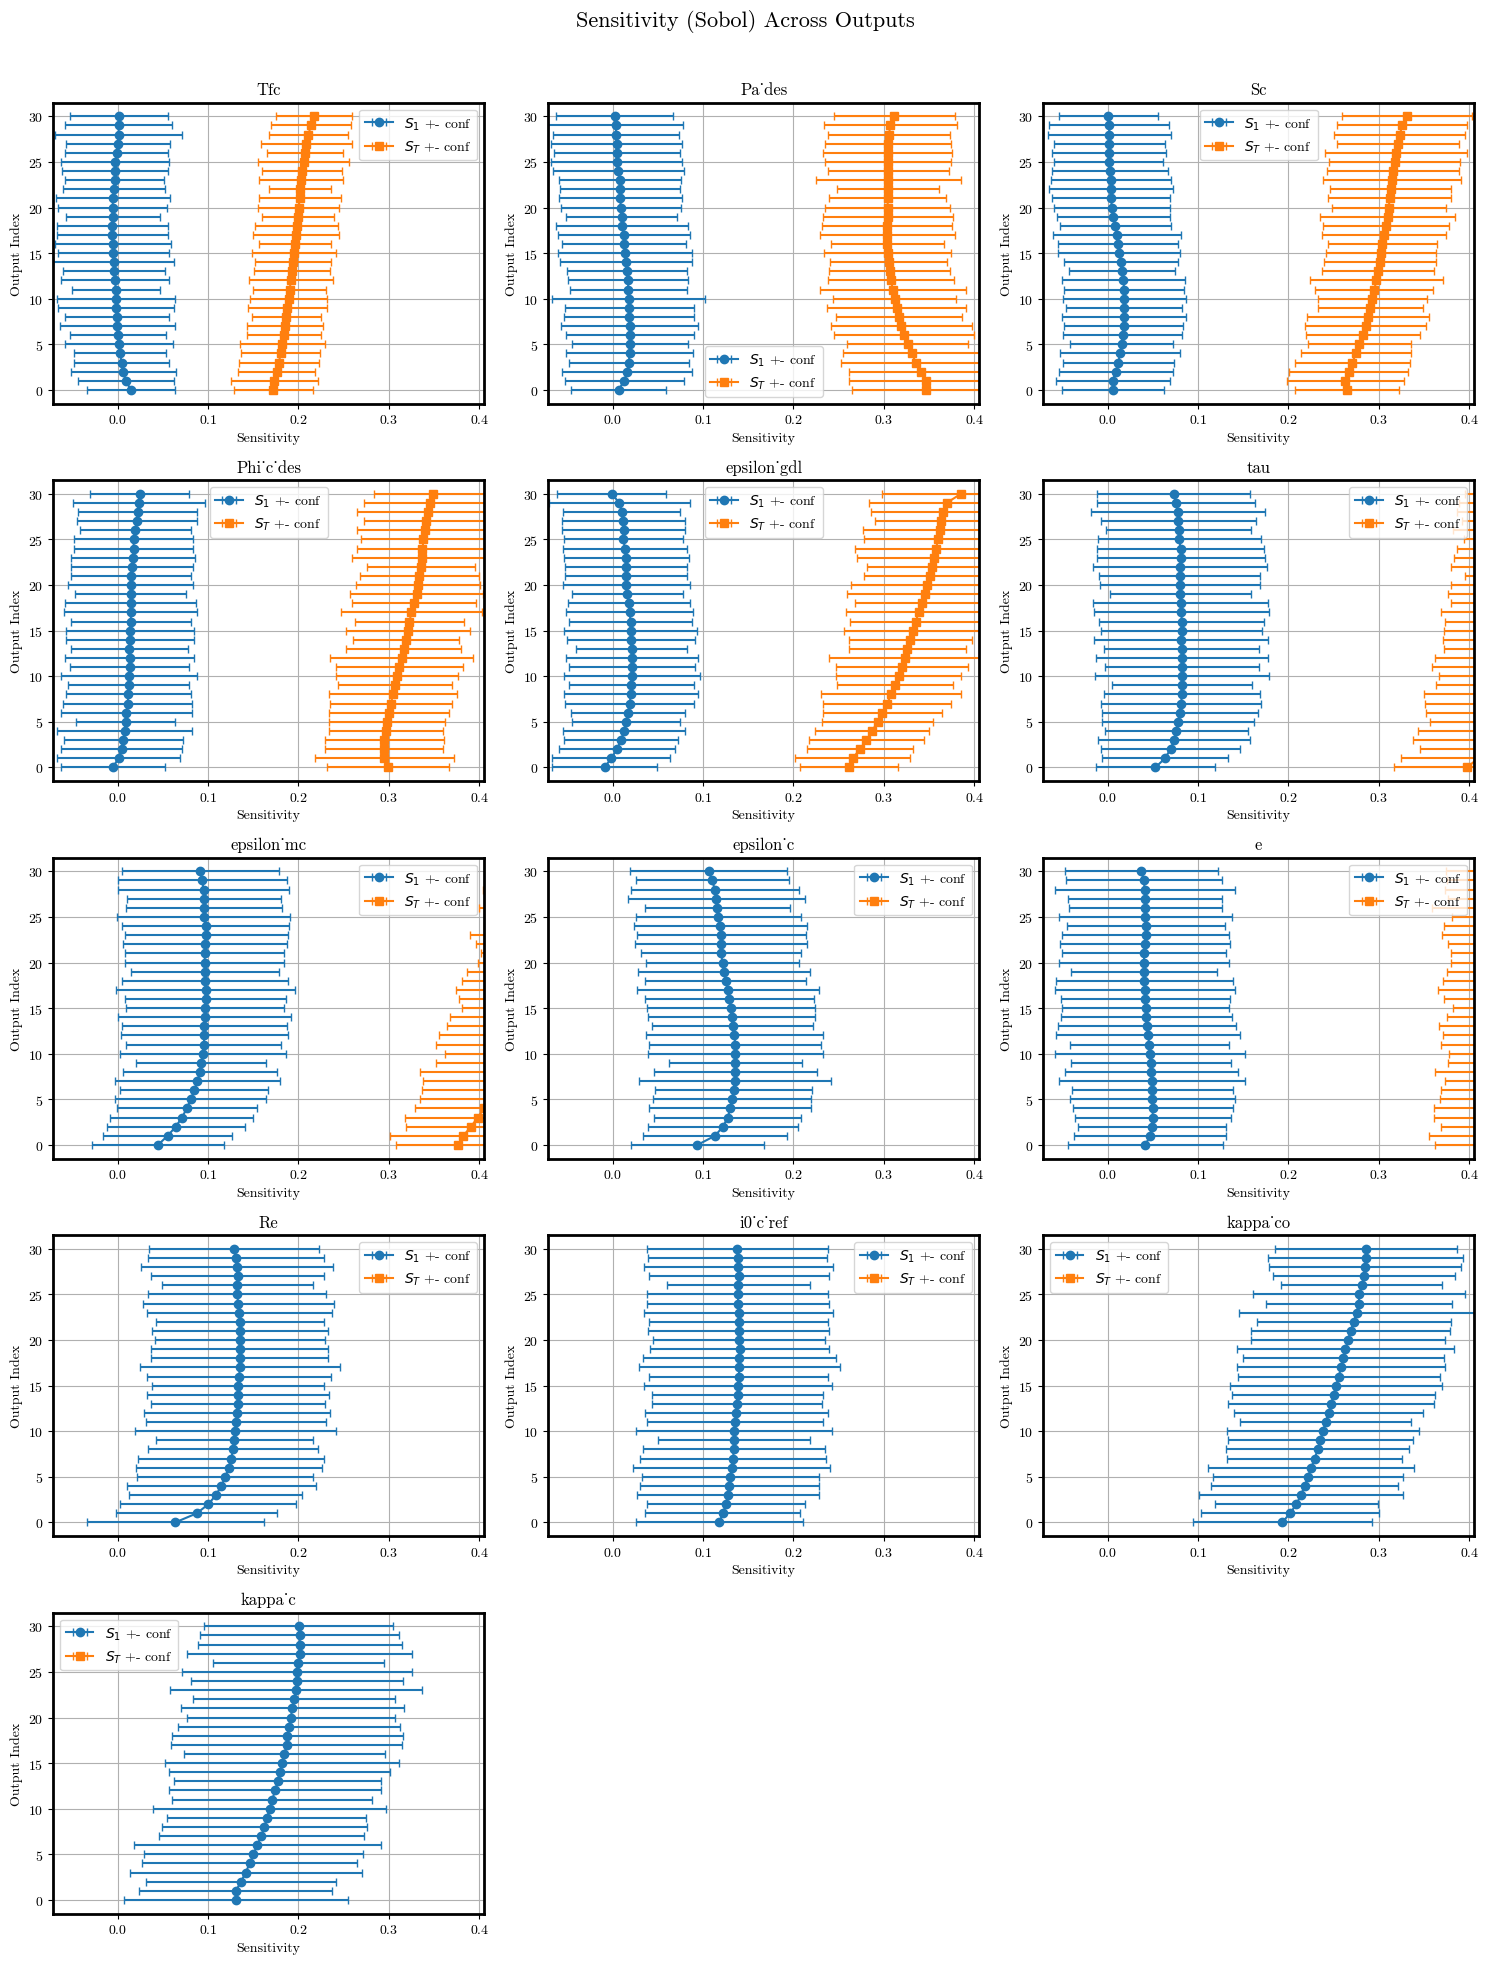

In [44]:
SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=512 , calculate_second_order=True)
samples = SA.generate_samples()
cols = list(samples.columns)
cols.append('Ucell')
cols.append('ifc')
results = SA.run_analysis(data[cols][:len(samples)], by_regions=None, aggregation_method=None)
SA.plot_grid(results)

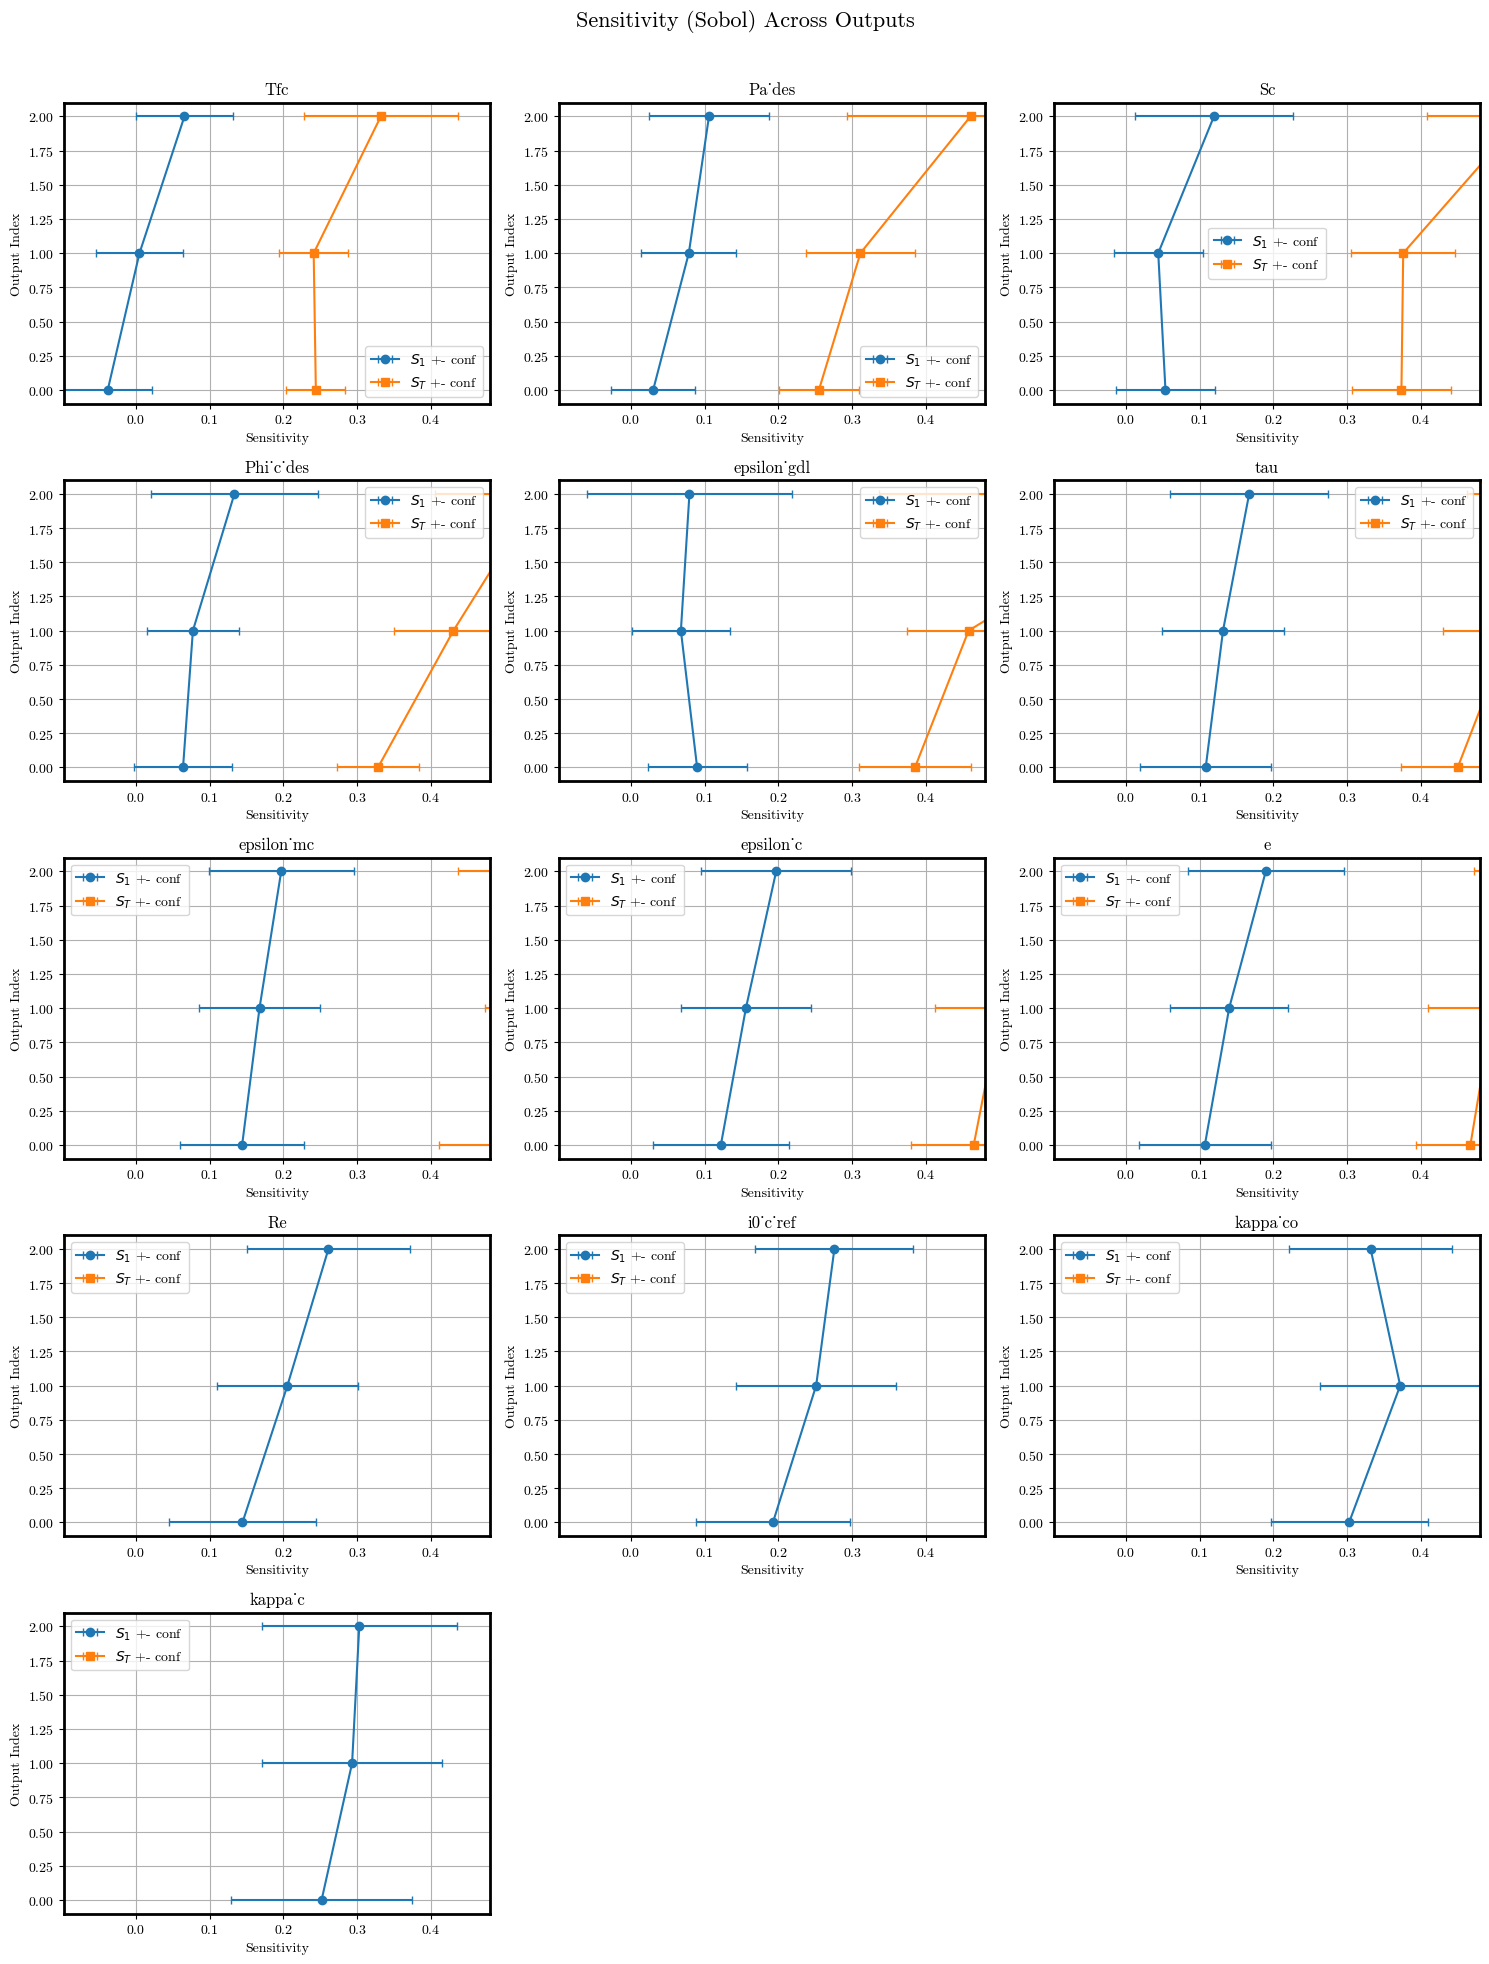

In [45]:
SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=512 , calculate_second_order=True)
samples = SA.generate_samples()
cols = list(samples.columns)
cols.append('Ucell')
cols.append('ifc')
results = SA.run_analysis(data[cols][:len(samples)], "AUC", by_regions=True)
SA.plot_grid(results)

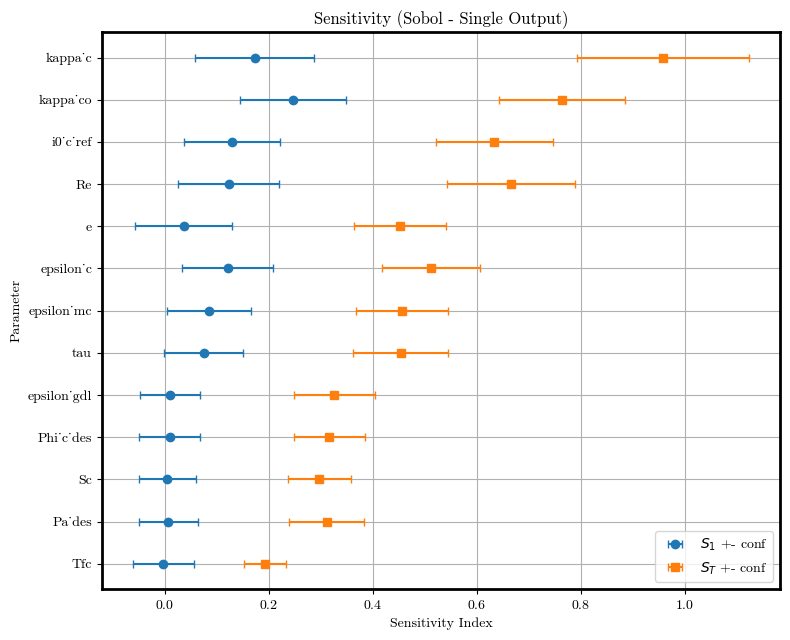

In [46]:
SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=512 , calculate_second_order=True)
samples = SA.generate_samples()
cols = list(samples.columns)
cols.append('Ucell')
cols.append('ifc')
results = SA.run_analysis(data[cols][:len(samples)], "AUC", by_regions=False)
SA.plot_grid(results)

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_rankings_for_Ns(parameter_ranges, data, Ns, aggregation_method):
    rankings = []
    param_names = None

    for N in Ns:
        SA = SensitivityAnalyzer(
            parameter_ranges,
            dependent_parameter_names=None,
            method='sobol',
            seed=42,
            N=N,
            calculate_second_order=True
        )
        samples = SA.generate_samples()
        subdata = data.iloc[:len(samples)]
        results = SA.run_analysis(subdata, aggregation_method=aggregation_method)

        # grab ST for output_index 0
        st = next(r['ST'] for r in results if r['output_index'] == 0)
        if param_names is None:
            param_names = results[0]['param']

        order = np.argsort(-st)     # descending
        ranks = np.empty_like(order)
        ranks[order] = np.arange(1, len(st)+1)
        rankings.append(dict(zip(param_names, ranks)))

    return pd.DataFrame(rankings, index=Ns)

import warnings
# 1) silence that specific FutureWarning
warnings.filterwarnings(
    "ignore",
    message="unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated"
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message="The balance properties of Sobol' points require n to be a power of 2"
)

# 1) build the full N list
Ns = list(range(2, 513, 4))   # [2, 6, 10, …, 254]

# 2) compute rank_df however you have it
rank_df = compute_rankings_for_Ns(parameter_ranges, data, Ns, aggregation_method="fPCA")



/var/folders/nh/g7l50kcx5r9g8d05q_6qbr000000gn/T/ipykernel_54501/453258985.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize="small", ncol=1)


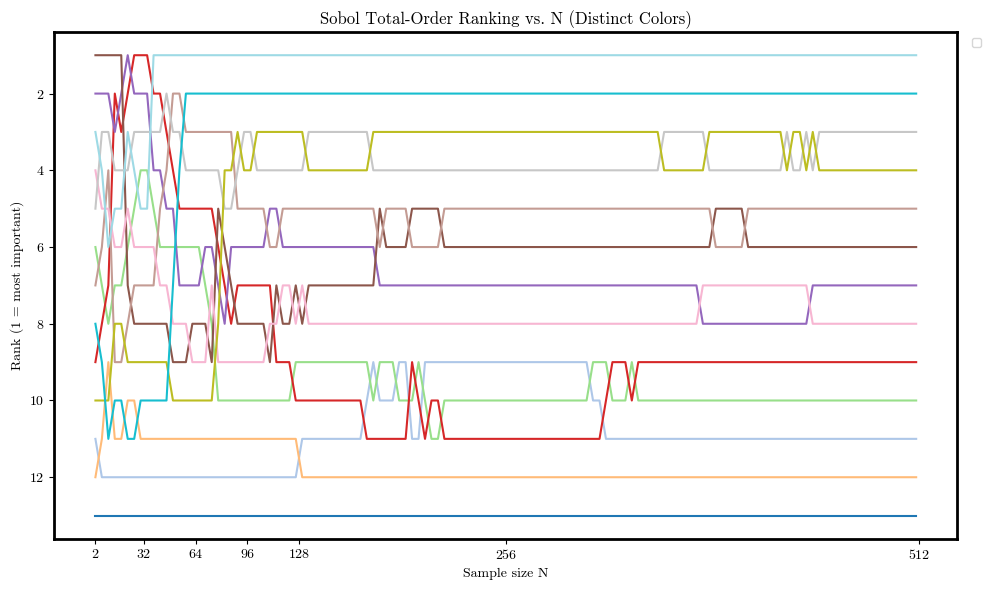

In [49]:

# 3) pick a colormap with at least as many colors as you have parameters
n_params = len(rank_df.columns)
cmap = plt.get_cmap('tab20', n_params)  # tab20 provides up to 20 distinct colors

plt.figure(figsize=(10, 6))
for idx, param in enumerate(rank_df.columns):
    y = rank_df[param].loc[Ns]
    plt.plot(Ns, y, color=cmap(idx))


plt.gca().invert_yaxis()
plt.xticks([2, 32, 64, 96, 128, 256, 512])
plt.xlabel("Sample size N")
plt.ylabel("Rank (1 = most important)")
plt.title("Sobol Total-Order Ranking vs. N (Distinct Colors)")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize="small", ncol=1)
plt.tight_layout()
plt.show()

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_indices_for_Ns(parameter_ranges, data, Ns, aggregation_method):
    """
    For each sample size N in Ns, run Sobol+fPCA analysis,
    extract total-order indices ST for the first output,
    and return a DataFrame of ST values (shape len(Ns) × n_params).
    """
    indices_list = []
    param_names = None

    for N in Ns:
        SA = SensitivityAnalyzer(
            parameter_ranges,
            dependent_parameter_names=None,
            method='sobol',
            seed=42,
            N=N,
            calculate_second_order=True
        )
        samples = SA.generate_samples()
        subdata = data.iloc[:len(samples)]
        results = SA.run_analysis(subdata, aggregation_method=aggregation_method)

        # extract S_T for output_index == 0
        st = next(r['ST'] for r in results if r['output_index'] == 0)
        if param_names is None:
            param_names = results[0]['param']

        indices_list.append(dict(zip(param_names, st)))

    return pd.DataFrame(indices_list, index=Ns)

# 1) define N sweep
Ns = list(range(2, 513, 4))  # [2, 3, …, 128]
# 2) collect ST values
st_df = compute_indices_for_Ns(parameter_ranges, data, Ns, aggregation_method="fPCA")


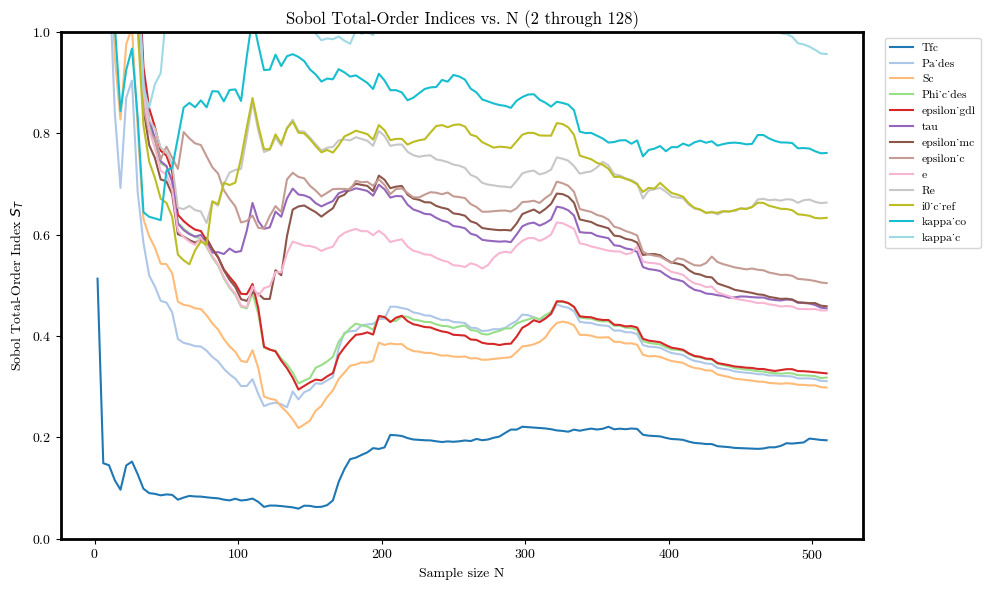

In [51]:

# 3) plot
cmap = plt.get_cmap('tab20', len(st_df.columns))

plt.figure(figsize=(10, 6))
for idx, param in enumerate(st_df.columns):
    plt.plot(
        st_df.index,
        st_df[param],
        label=param,
        color=cmap(idx)
    )

plt.xlabel("Sample size N")
plt.ylabel("Sobol Total-Order Index $S_T$")
plt.title("Sobol Total-Order Indices vs. N (2 through 128)")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize="small")
plt.tight_layout()
plt.show()

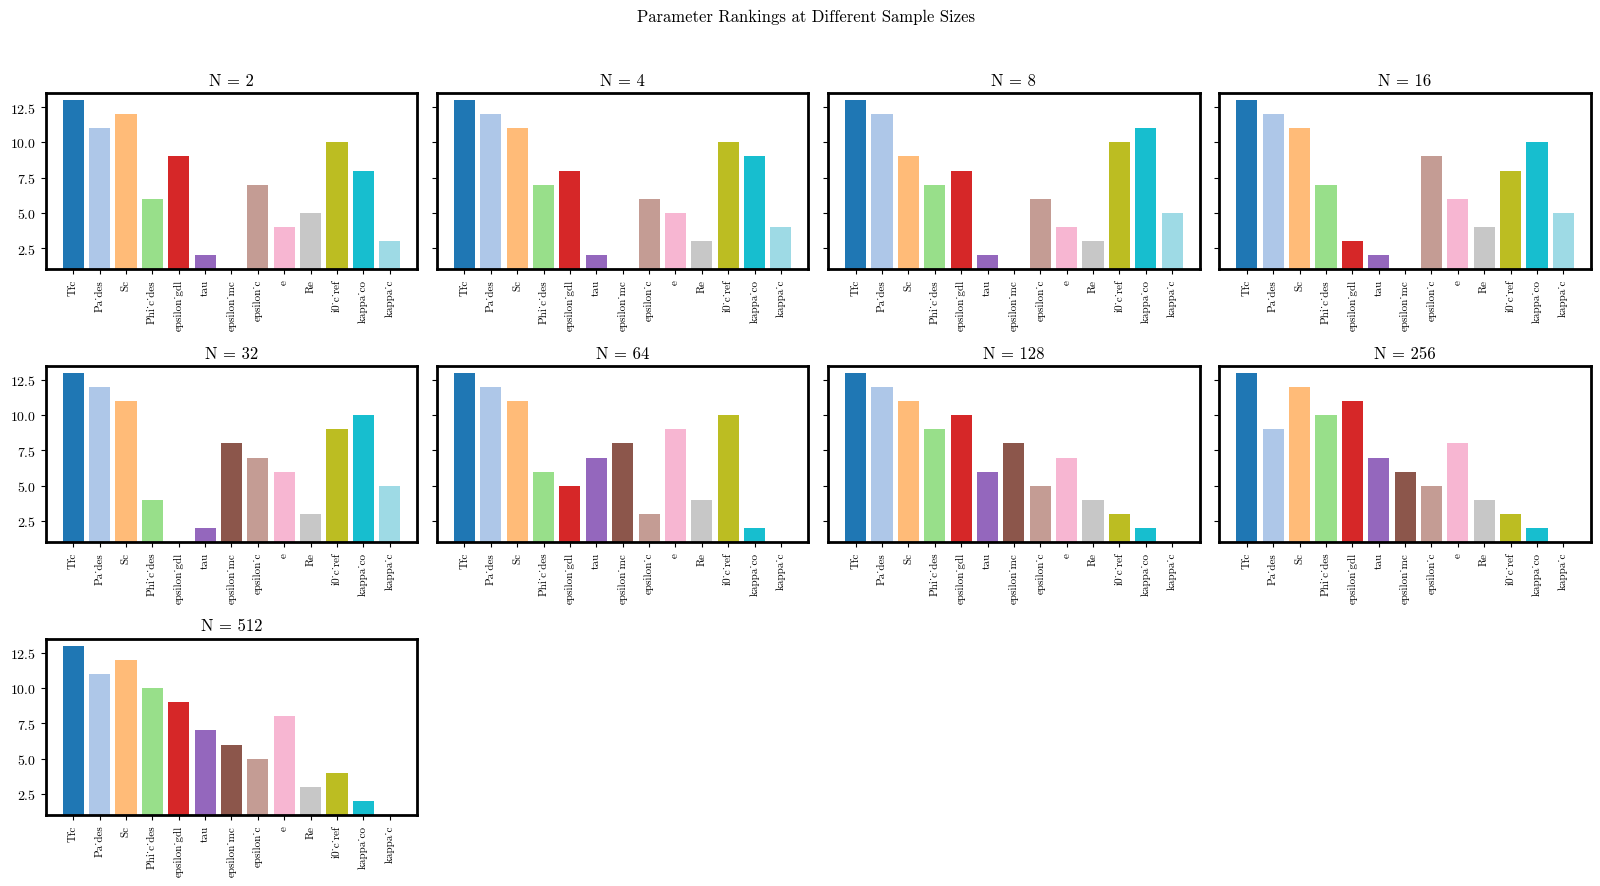

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose rank_df is your DataFrame of shape (len(Ns) × n_params), indexed by Ns
Ns = [2**i for i in range(1, 10)]         # [2, 4, 8, …, 256]

# 2) compute rank_df however you have it
rank_df = compute_rankings_for_Ns(parameter_ranges, data, Ns, aggregation_method="fPCA")
params = rank_df.columns.tolist()
n_params = len(params)

# Decide grid dimensions: e.g. 2 rows × 4 cols for eight plots
n_cols = 4
n_rows = int(np.ceil(len(Ns) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 3 * n_rows),
    sharey=True  # keep y-axis scale consistent
)

for ax, N in zip(axes.flat, Ns):
    # Get the ranking vector for this N
    ranks = rank_df.loc[N]

    # Draw a bar plot: x = parameter index, height = rank
    ax.bar(
        np.arange(n_params),
        ranks,
        color=plt.get_cmap('tab20', n_params).colors  # one distinct color per bar
    )
    ax.set_title(f"N = {N}")
    ax.set_xticks(np.arange(n_params))
    ax.set_xticklabels(params, rotation=90, fontsize=8)
    ax.invert_yaxis()             # rank 1 at top
    ax.set_ylim(1, n_params + 0.5)

# Turn off any unused subplots
for idx in range(len(Ns), n_rows * n_cols):
    fig.delaxes(axes.flat[idx])

fig.suptitle("Parameter Rankings at Different Sample Sizes")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Font 'default' does not have a glyph for '\u2010' [U+2010], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2010' [U+2010], substituting with a dummy symbol.


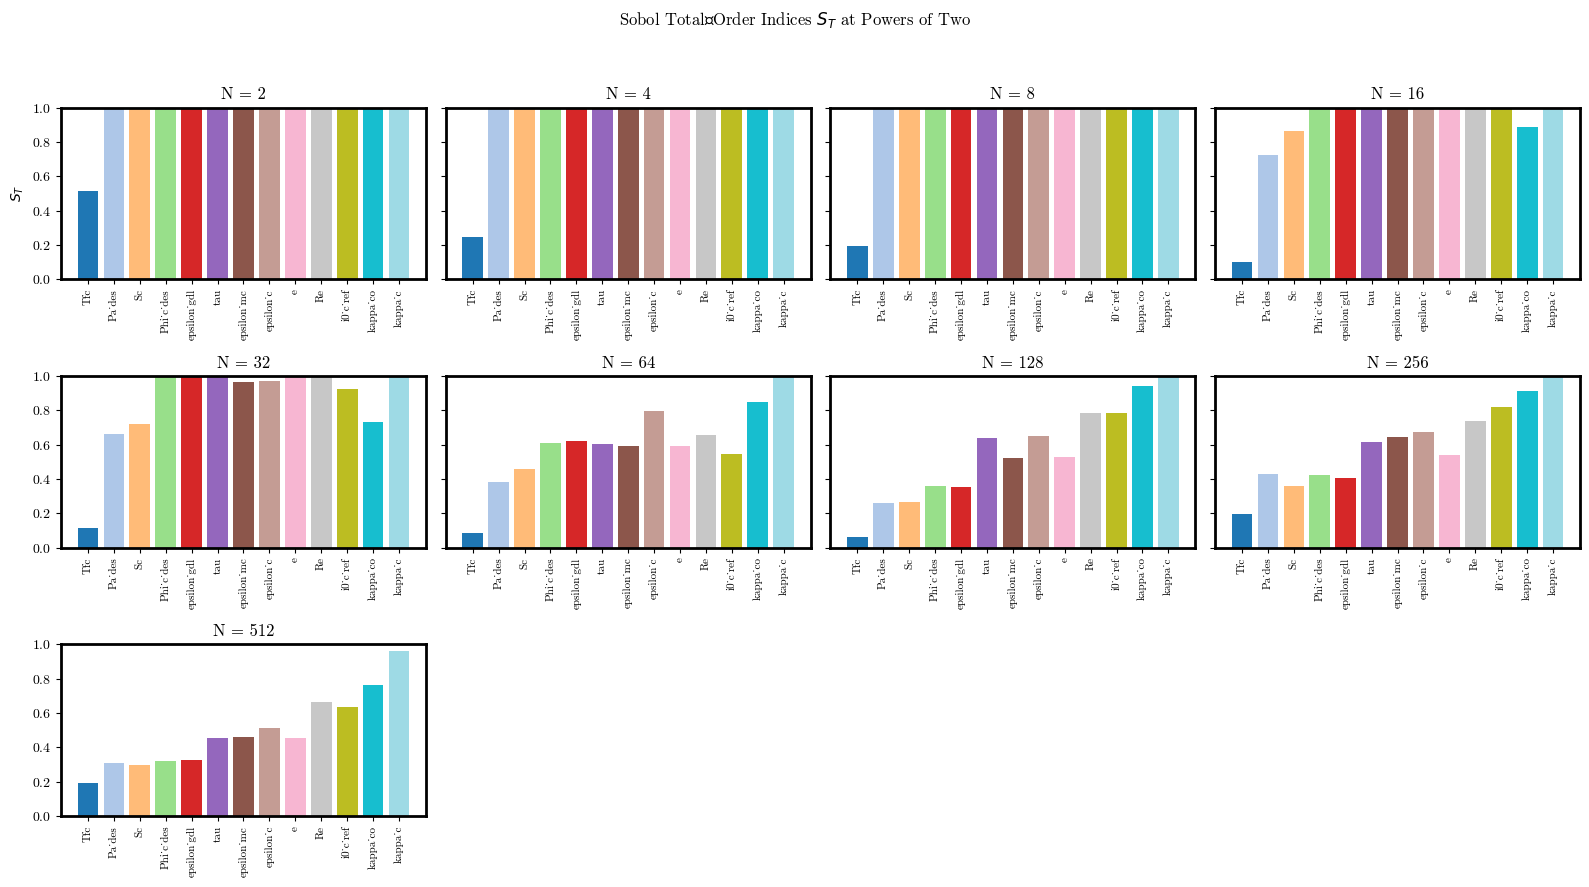

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# 1) powers‐of‐two Ns
Ns = [2**i for i in range(1, 10)]   # [2, 4, 8, 16, 32, 64, 128, 256]
# 2) collect ST values
st_df = compute_indices_for_Ns(parameter_ranges, data, Ns, aggregation_method="fPCA")


params = st_df.columns.tolist()
n_params = len(params)

# 3) grid setup: 2 rows × 4 cols
n_cols = 4
n_rows = int(np.ceil(len(Ns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharey=True)

# 4) bar‐plot each N’s indices
colors = plt.get_cmap('tab20', n_params).colors
for ax, N in zip(axes.flat, Ns):
    indices = st_df.reindex(Ns).loc[N]  # ensure alignment

    ax.bar(
        np.arange(n_params),
        indices,
        color=colors
    )
    ax.set_title(f"N = {N}")
    ax.set_xticks(np.arange(n_params))
    ax.set_xticklabels(params, rotation=90, fontsize=8)
    ax.set_ylim(0, 1)               # Sobol indices in [0,1]
    ax.set_ylabel("$S_T$" if ax is axes.flat[0] else "")

# 5) clean up any empty subplots
for idx in range(len(Ns), n_rows * n_cols):
    fig.delaxes(axes.flat[idx])

fig.suptitle("Sobol Total‐Order Indices $S_T$ at Powers of Two")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


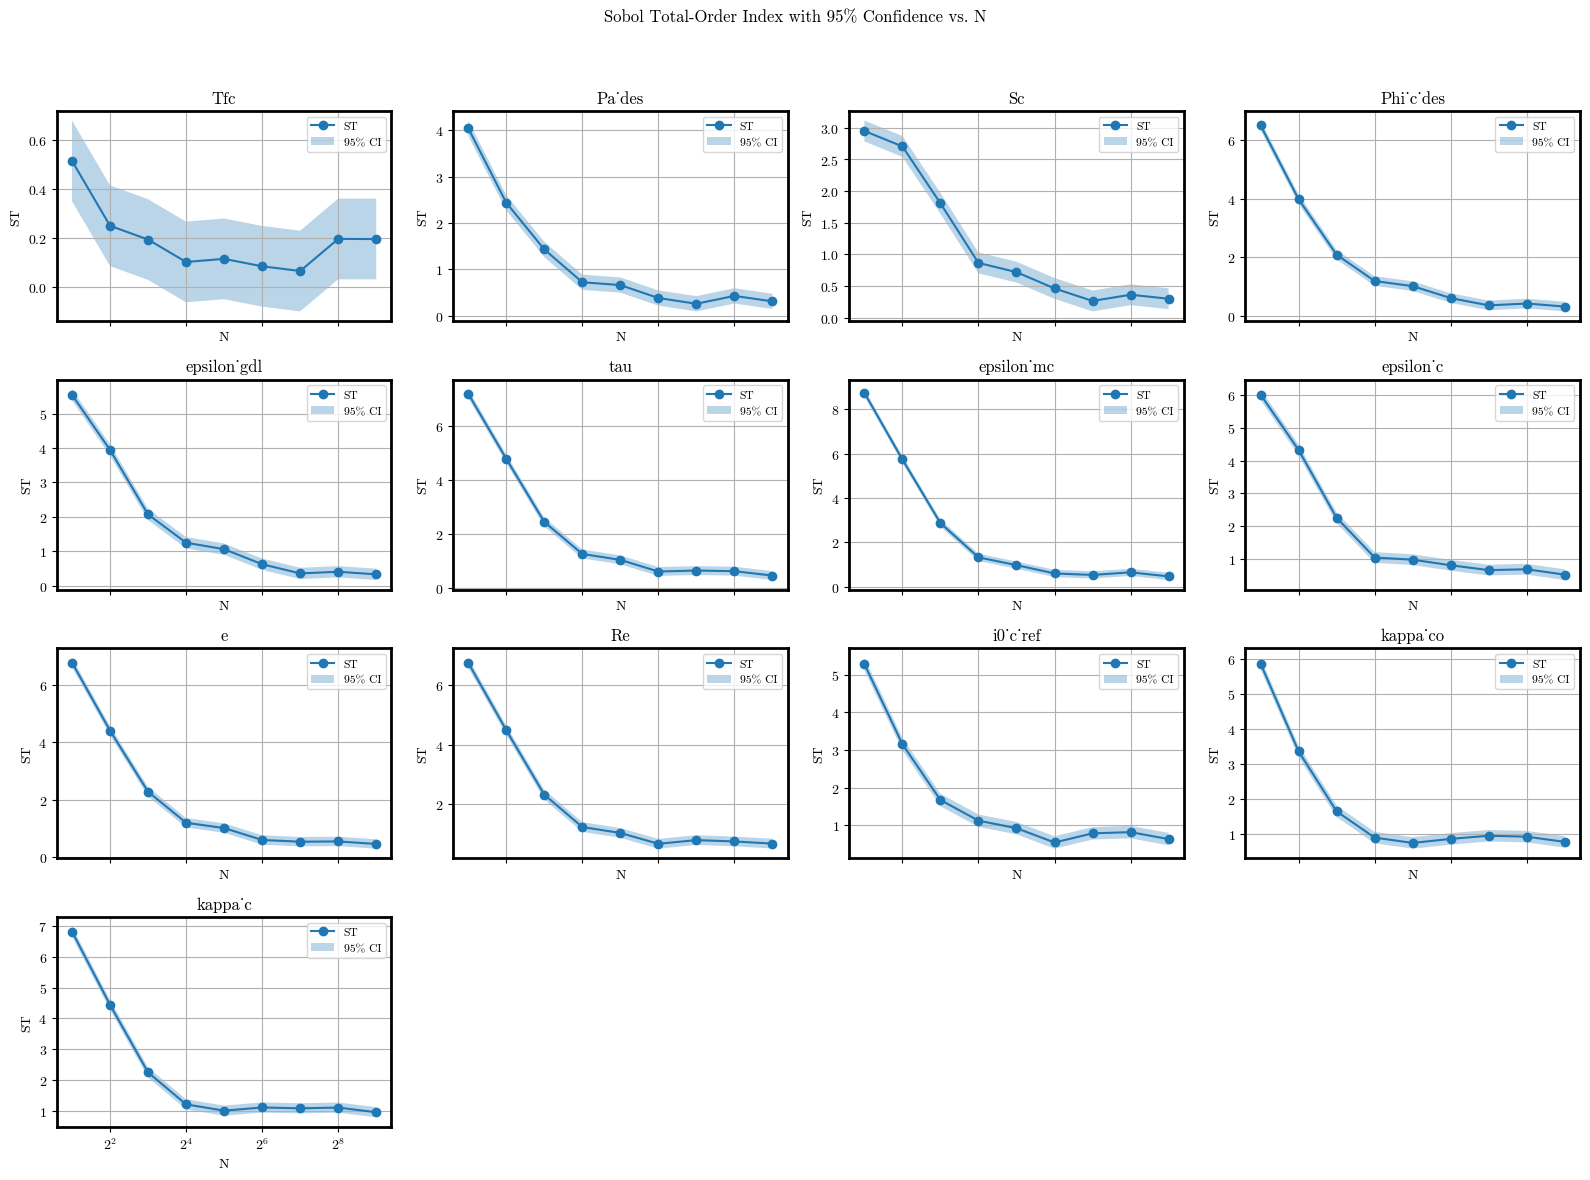

In [54]:
import numpy as np
import matplotlib.pyplot as plt

def plot_index_with_confidence(parameter_ranges, data, Ns, **SA_kwargs):
    """
    For each Sobol parameter, plot its total-order index and confidence interval vs N.
    
    parameter_ranges: dict of ranges passed to SensitivityAnalyzer
    data: DataFrame containing 'Ucell' and 'ifc' columns
    Ns: list of sample sizes (powers of two)
    SA_kwargs: other kwargs for SensitivityAnalyzer (method, seed, calculate_second_order)
    """
    # Storage for each parameter: dict mapping param -> list of (N, ST, ST_conf)
    ci_data = {}
    # Run for each N
    for N in Ns:
        SA = SensitivityAnalyzer(parameter_ranges, method='sobol', seed=42, N=N, calculate_second_order=True)
        samples = SA.generate_samples()
        cols = list(samples.columns) + ['Ucell', 'ifc']
        results = SA.run_analysis(data[cols].iloc[:len(samples)], aggregation_method="fPCA")
        # Extract ST and ST_conf for output 0
        for res in results:
            if res['output_index'] == 0:
                for param, st, conf in zip(res['param'], res['ST'], res['ST_conf']):
                    ci_data.setdefault(param, []).append((N, st, conf))
                break

    # Now plot one subplot per parameter
    n_params = len(ci_data)
    cols = 4
    rows = int(np.ceil(n_params / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), sharex=True, sharey=False)
    
    for ax, (param, vals) in zip(axes.flat, ci_data.items()):
        vals_sorted = sorted(vals, key=lambda x: x[0])
        Ns_plot, sts, confs = zip(*vals_sorted)
        sts = np.array(sts)
        confs = np.array(confs)
        ax.plot(Ns_plot, sts, marker='o', label='ST')
        ax.fill_between(Ns_plot, sts-conf, sts+conf, alpha=0.3, label='95% CI')
        ax.set_xscale('log', base=2)
        ax.set_title(param)
        ax.set_xlabel("N")
        ax.set_ylabel("ST")
        ax.grid(True)
        ax.legend(loc='upper right', fontsize='small')
    
    # Remove any extra axes
    for idx in range(n_params, rows*cols):
        fig.delaxes(axes.flat[idx])

    fig.suptitle("Sobol Total-Order Index with 95% Confidence vs. N")
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Example usage:
Ns = [2,4,8,16,32,64,128, 256, 512]
plot_index_with_confidence(parameter_ranges, data, Ns)


/var/folders/nh/g7l50kcx5r9g8d05q_6qbr000000gn/T/ipykernel_54501/491004719.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 0.95])


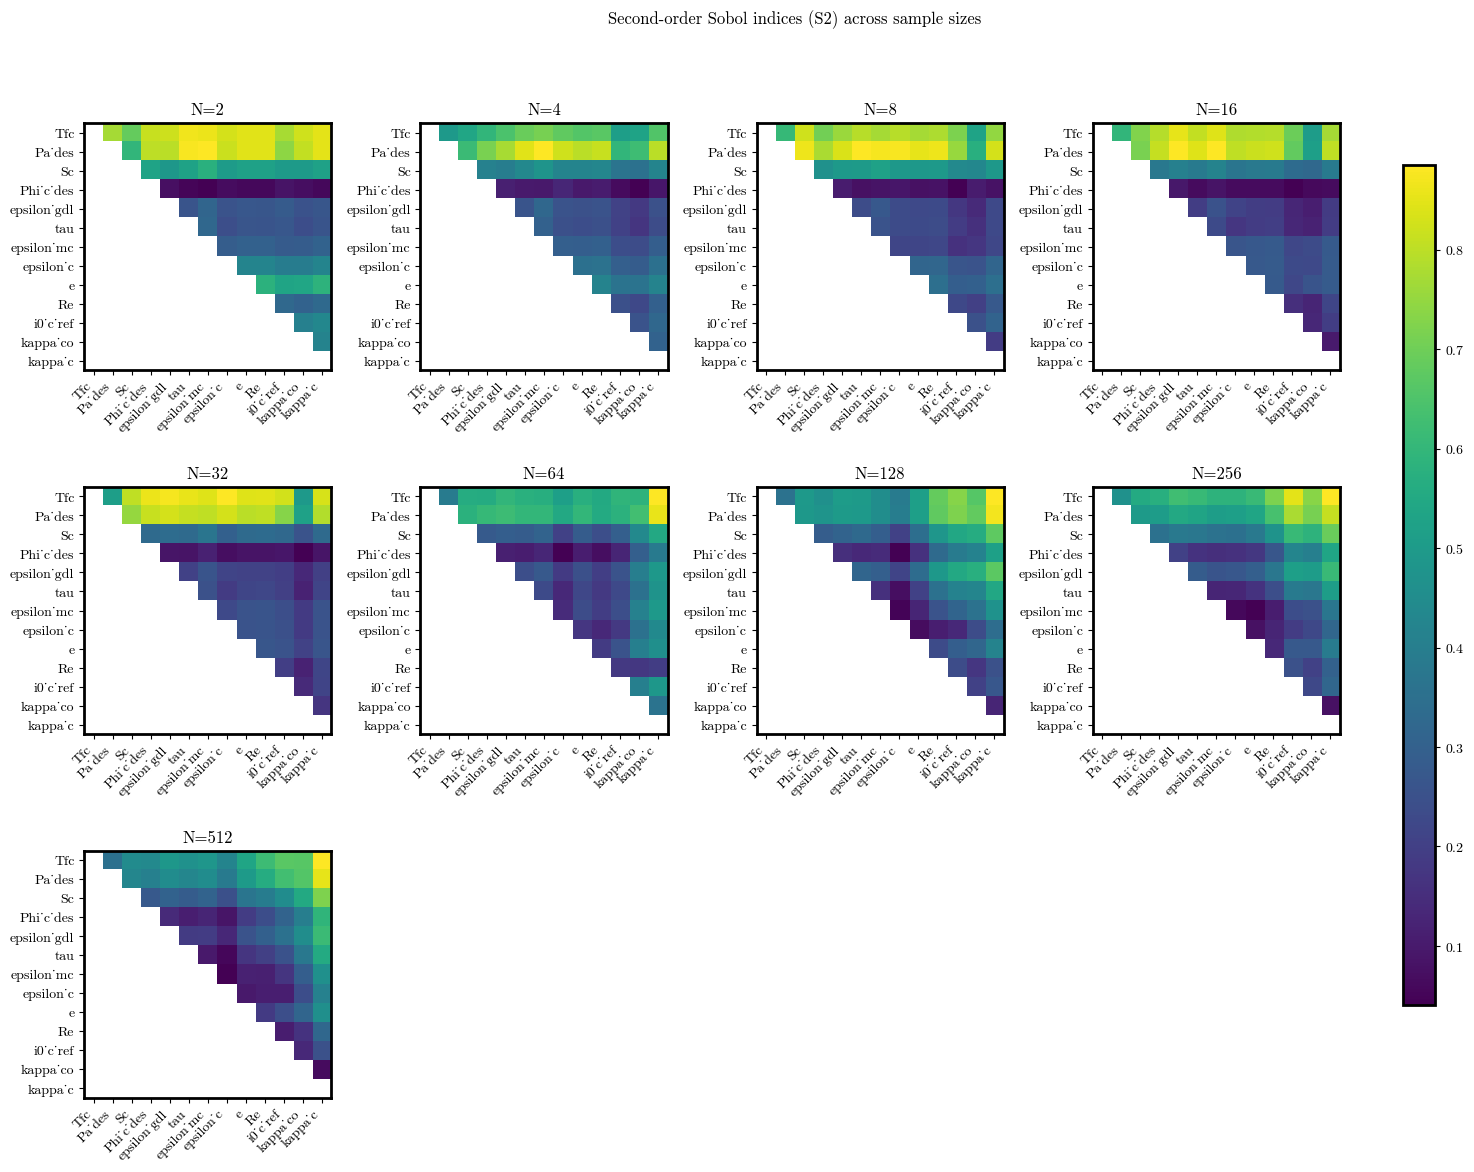

In [55]:
import numpy as np
import matplotlib.pyplot as plt

def plot_all_sobol_s2(results, param_names=None, ncols=4, figsize_per_plot=(4, 4), cmap='viridis'):
    """
    Plot all second-order Sobol indices (S2) heatmaps from a list of Sobol results in a grid layout.

    Parameters:
        results (list of dict): each dict contains keys 'param', 'S2', and should include 'N' for sample size.
        param_names (list of str, optional): common parameter names. If None, uses each entry's 'param'.
        ncols (int): number of columns in the grid.
        figsize_per_plot (tuple): width and height for each subplot in inches.
        cmap (str): matplotlib colormap name.

    Raises:
        ValueError: if any entry lacks 'S2' data.
    """
    nplots = len(results)
    if nplots == 0:
        raise ValueError("No results to plot.")

    # Determine grid size
    nrows = int(np.ceil(nplots / ncols))
    fig_width = figsize_per_plot[0] * ncols
    fig_height = figsize_per_plot[1] * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height), squeeze=False)

    for idx, entry in enumerate(results):
        row = idx // ncols
        col = idx % ncols
        ax = axes[row][col]

        # Extract and validate S2 matrix
        S2 = np.array(entry.get('S2', []))
        if S2.size == 0:
            raise ValueError(f"Entry at index {idx} has no 'S2'")

        # Determine parameter names
        names = param_names or entry.get('param')
        if names is None:
            n = S2.shape[0]
            names = [f'x{i}' for i in range(n)]

        # Reshape if needed
        n = len(names)
        if S2.shape != (n, n):
            try:
                S2 = S2.reshape((n, n))
            except Exception:
                raise ValueError(f"Cannot reshape S2 of shape {S2.shape} into ({n},{n})")

        # Plot heatmap on subplot
        cax = ax.imshow(S2, interpolation='nearest', cmap=cmap)
        ax.set_xticks(np.arange(n))
        ax.set_yticks(np.arange(n))
        ax.set_xticklabels(names, rotation=45, ha='right')
        ax.set_yticklabels(names)

        # Title using sample size N
        if 'N' in entry:
            ax.set_title(f"N={entry['N']}")
        else:
            ax.set_title(f"Run {idx}")

    # Hide unused subplots
    for idx in range(nplots, nrows * ncols):
        row = idx // ncols
        col = idx % ncols
        axes[row][col].axis('off')

    # Add colorbar
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    fig.colorbar(cax, cax=cbar_ax)
    fig.suptitle('Second-order Sobol indices (S2) across sample sizes')
    plt.tight_layout(rect=[0, 0, 0.85, 0.95])
    plt.show()


results = []
for N in Ns:
    SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=N , calculate_second_order=True)
    samples = SA.generate_samples()
    cols = list(samples.columns)
    cols.append('Ucell')
    cols.append('ifc')
    results.append(SA.run_analysis(data[cols][:len(samples)], "fPCA")[0])

# Ensure each result dict includes 'N' key before plotting:
for i, N in enumerate(Ns):
     results[i]['N'] = N
# Example usage:
plot_all_sobol_s2(results)


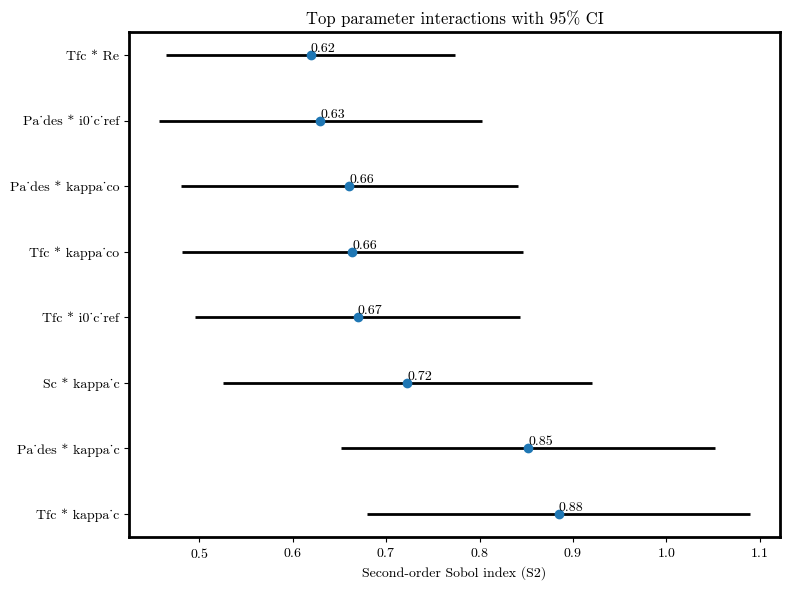

In [56]:
import itertools
def plot_forest_interactions(results, param_names=None, top_k=10, include_ci=True, sort_desc=True, figsize=(8, 6), fmt=".2f", line_kwargs=None, marker_kwargs=None, text_kwargs=None):
    '''
    Plot a forest-style plot of top-k parameter interactions with confidence intervals.

    Each interaction is shown on the y-axis, with a horizontal line for the confidence interval
    and a central marker for the mean S2 value.

    Parameters:
        results (list of dict): one Sobol result dict (or list where only the first is used).
        param_names (list of str, optional): parameter names. If None, uses result['param'].
        top_k (int): number of top interactions to display.
        include_ci (bool): whether to plot confidence intervals from 'S2_conf'.
        sort_desc (bool): sort interactions by descending S2.
        figsize (tuple): figure size (width, height).
        fmt (str): format string for annotating mean values.
        line_kwargs (dict, optional): kwargs for hlines (e.g., linewidth).
        marker_kwargs (dict, optional): kwargs for plot markers (e.g., marker style).
        text_kwargs (dict, optional): kwargs for annotation text (fontsize, va, etc.).

    Raises:
        ValueError: if S2 data is missing.
    '''
    entry = results[0] if isinstance(results, list) else results
    S2 = np.array(entry.get('S2', []))
    ci = np.array(entry.get('S2_conf', [])) if include_ci else None
    if S2.size == 0:
        raise ValueError('No S2 data found.')

    names = param_names or entry.get('param')
    if names is None:
        n = S2.shape[0]
        names = [f'x{i}' for i in range(n)]

    n = len(names)
    pairs = list(itertools.combinations(range(n), 2))
    vals = [S2[i, j] for i, j in pairs]
    errs = [ci[i, j] if include_ci else 0 for i, j in pairs]

    interactions = [((names[i], names[j]), v, e) for (i, j), v, e in zip(pairs, vals, errs)]
    interactions.sort(key=lambda x: x[1], reverse=sort_desc)
    top = interactions[:top_k]

    labels = [f'{a} * {b}' for (a, b), _, _ in top]
    means = [v for _, v, _ in top]
    cis = [e for _, _, e in top]

    # Reverse for plotting top at top
    labels = labels[::-1]
    means = means[::-1]
    cis = cis[::-1]
    y_pos = np.arange(len(labels))

    if line_kwargs is None:
        line_kwargs = {'linewidth': 2}
    if marker_kwargs is None:
        marker_kwargs = {'marker': 'o', 'linestyle': ''}
    if text_kwargs is None:
        text_kwargs = {'fontsize': 10, 'va': 'bottom'}

    fig, ax = plt.subplots(figsize=figsize)
    # Plot CIs as horizontal lines
    if include_ci:
        for y, mean, ci_val in zip(y_pos, means, cis):
            ax.hlines(y, mean - ci_val, mean + ci_val, color='black', **line_kwargs)
    # Plot mean markers
    ax.plot(means, y_pos, **marker_kwargs)

    # Annotate mean values above markers
    for x, y in zip(means, y_pos):
        ax.text(x, y, format(x, fmt), **text_kwargs)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Second-order Sobol index (S2)')
    ax.set_title('Top parameter interactions with 95% CI')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
plot_forest_interactions(results[-1], top_k=8)

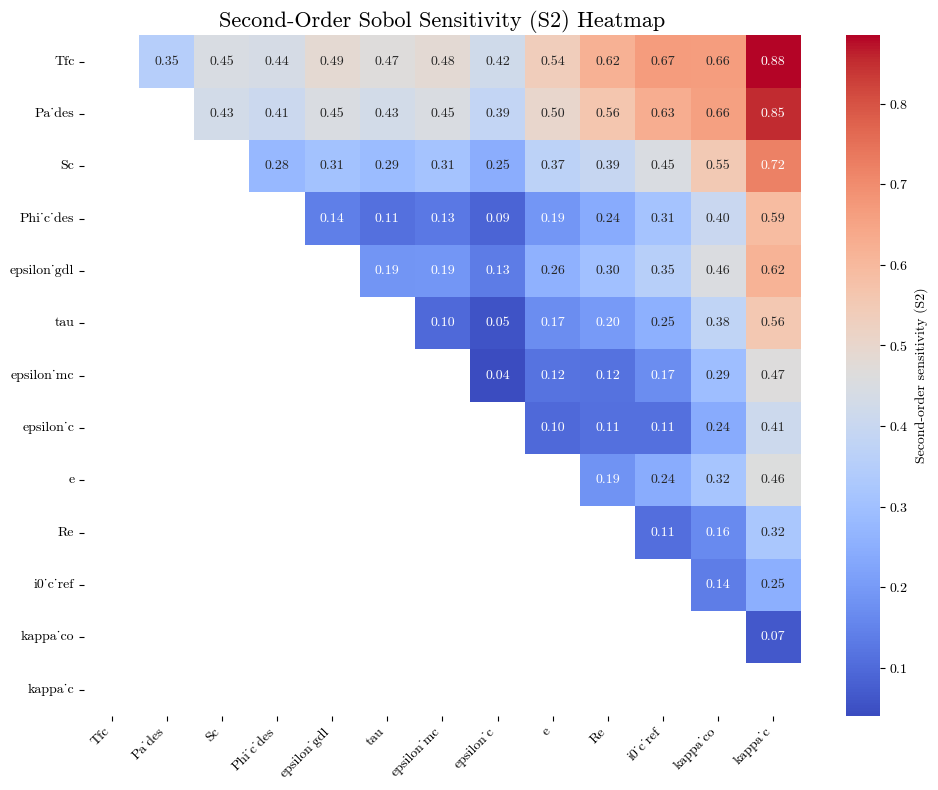

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # For nicer heatmaps

def plot_sobol_S2_heatmap(sobol_result):
    """
    Plots the S2 (second-order Sobol indices) as a heatmap.
    
    Parameters:
        sobol_result (dict): Single output's Sobol sensitivity analysis result.
        problem (dict): Dictionary containing problem information, including parameter names.
    """
    param_names = sobol_result['param']
    n_params = len(param_names)
    
    # Extract S2 matrix
    S2_matrix = np.zeros((n_params, n_params))

    for i in range(n_params):
        for j in range(n_params):
            if i == j:
                S2_matrix[i, j] = np.nan  # You can decide to put NaN or 0 on the diagonal (no self-interaction)
            else:
                S2_matrix[i, j] = sobol_result['S2'][i][j]

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(S2_matrix, 
                xticklabels=param_names, 
                yticklabels=param_names, 
                cmap="coolwarm", 
                annot=True, 
                fmt=".2f", 
                mask=np.isnan(S2_matrix),
                cbar_kws={'label': 'Second-order sensitivity (S2)'})
    
    plt.title('Second-Order Sobol Sensitivity (S2) Heatmap', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_sobol_S2_heatmap(results[-1])